# **🚀 Customer Churn Prediction System**  
### 📊 Superstore Dataset | Predictive Customer Intelligence

**Author:** Daniel Damilola Amosun  
**Organization:** InferaIQ  
**Role:** Data Scientist / AI Engineer  

---

## 📖 Business Context  

Customer retention is a key driver of profitability. Customer churn increases acquisition costs, reduces customer lifetime value (CLV), and leads to inefficient allocation of marketing resources.  

Organizations that do not proactively manage churn risk often experience revenue decline and reduced long-term customer value.

---

## 🚨 Problem Statement  

Most businesses react to churn after it occurs, rather than identifying at-risk customers in advance.  

The objective of this project is to develop a predictive machine learning system that identifies customers with high churn risk, enabling targeted and proactive retention strategies.

---

## 🛠️ Tools & Technologies  

- **Programming:** Python  
- **Data Processing:** Pandas, NumPy  
- **Visualization:** Matplotlib, Seaborn  
- **Machine Learning:** Scikit-learn, XGBoost, Imbalanced-learn  
- **Explainability:** SHAP  
- **Experiment Tracking:** MLflow  
- **Deployment:** FastAPI, Streamlit  
- **Model Storage:** Joblib  
- **API Validation:** Pydantic  
- **Configuration Management:** Python-dotenv  
---

## 🏗️ System Architecture  
Data → Cleaning → RFM → Feature Engineering → ML Model → Evaluation → SHAP → API → Dashboard



## ⚙️ Environment Setup & Dependency Installation

In [1]:
# This step ensures all required libraries are available,
# making the notebook reproducible across different environments.

# Install core dependencies for:
# - model training (xgboost)
# - handling class imbalance (imbalanced-learn)
# - explainability (shap)
# - experiment tracking (mlflow)
# - visualization (matplotlib, seaborn)
# - The "-q" flag reduces installation verbosity for cleaner notebook output.

!pip install -q mlflow shap xgboost imbalanced-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

## 📚 Import Libraries

In [2]:
# Core Libraries
import pandas as pd
import numpy as np
import os
import joblib

# File Handling
import zipfile
import shutil

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
from xgboost import XGBClassifier

# Model Explainability
import shap

# Experiment Tracking
import mlflow
import mlflow.sklearn

# Statistical Testing (Drift Detection)
from scipy.stats import ks_2samp

## 📂 Load Data

In [3]:
# Load dataset
df = pd.read_csv("superstore.csv")

# Preview data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2020-152156,11/08/2020,11/11/2020,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2020-152156,11/08/2020,11/11/2020,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2020-138688,06/12/2020,06/16/2020,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2019-108966,10/11/2019,10/18/2019,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2019-108966,10/11/2019,10/18/2019,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 🧩 Data Preparation & RFM Pipeline



In [4]:
# Convert order date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Remove missing values
df = df.dropna()

# Define reference date for recency calculation
reference_date = df["Order Date"].max()

# Aggregate customer-level metrics (RFM)
rfm = df.groupby("Customer ID").agg({
    "Order Date": lambda x: (reference_date - x.max()).days,  # Recency
    "Order ID": "nunique",                                    # Frequency
    "Sales": "sum",                                           # Monetary
    "Profit": "sum"
}).reset_index()

# Rename columns for clarity
rfm.columns = ["Customer ID", "Recency", "Frequency", "Monetary", "Profit"]

# Create additional behavioral features
rfm["AOV"] = rfm["Monetary"] / rfm["Frequency"]
rfm["Purchase_Frequency"] = rfm["Frequency"]
rfm["Tenure"] = rfm["Recency"]

# Handle division and missing value issues
rfm.replace([np.inf, -np.inf], 0, inplace=True)
rfm.fillna(0, inplace=True)

# Define churn based on business rules
rfm["Churn"] = (
    (rfm["Recency"] > 90) &
    (rfm["Frequency"] < 3) &
    (rfm["Monetary"] < 500)
).astype(int)

# Preview engineered dataset
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Profit,AOV,Purchase_Frequency,Tenure,Churn
0,AA-10315,184,5,5563.560,-362.8825,1112.712000,5,184,0
1,AA-10375,19,9,1056.390,277.3824,117.376667,9,19,0
2,AA-10480,259,4,1790.512,435.8274,447.628000,4,259,0
3,AA-10645,55,6,5086.935,857.8033,847.822500,6,55,0
4,AB-10015,415,3,886.156,129.3465,295.385333,3,415,0


## 🧠 RFM Scoring & Segmentation

In [5]:
# Create RFM scores using quantiles
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

# Convert scores to integer
rfm["R_score"] = rfm["R_score"].astype(int)
rfm["F_score"] = rfm["F_score"].astype(int)
rfm["M_score"] = rfm["M_score"].astype(int)

# Combine RFM scores
rfm["RFM_Score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

# Assign customer segments based on RFM profile
def segment_customer(row):
    if row["RFM_Score"] >= 13:
        return "Champions"
    elif row["R_score"] >= 4 and row["F_score"] >= 3:
        return "Loyal Customers"
    elif row["R_score"] == 5:
        return "Recent Customers"
    elif row["R_score"] <= 2 and row["F_score"] <= 2:
        return "At Risk"
    else:
        return "Others"

# Apply segmentation
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

## 📊 Exploratory Data Analysis


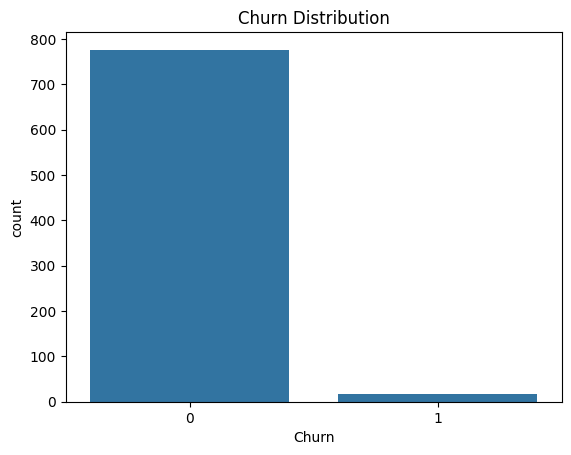

Insight: Churn group is smaller but business-critical.


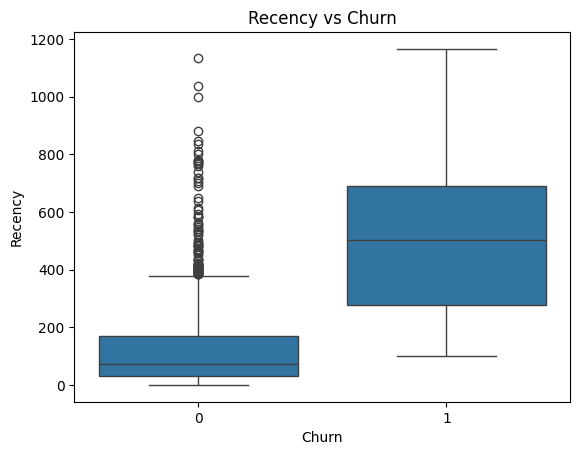

Insight: Higher recency is associated with churn.


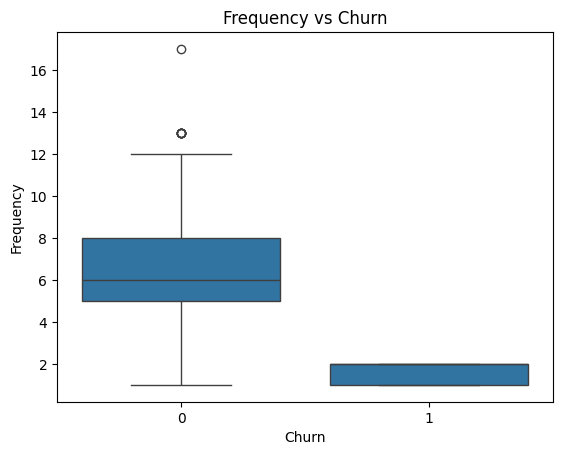

Insight: Low-frequency customers are more likely to churn.


In [6]:
# Plot churn distribution
sns.countplot(x='Churn', data=rfm)
plt.title("Churn Distribution")
plt.show()

print("Insight: Churn group is smaller but business-critical.")

# Analyze recency vs churn
sns.boxplot(x='Churn', y='Recency', data=rfm)
plt.title("Recency vs Churn")
plt.show()

print("Insight: Higher recency is associated with churn.")

# Analyze frequency vs churn
sns.boxplot(x='Churn', y='Frequency', data=rfm)
plt.title("Frequency vs Churn")
plt.show()

print("Insight: Low-frequency customers are more likely to churn.")

## 📈 Segment Analysis

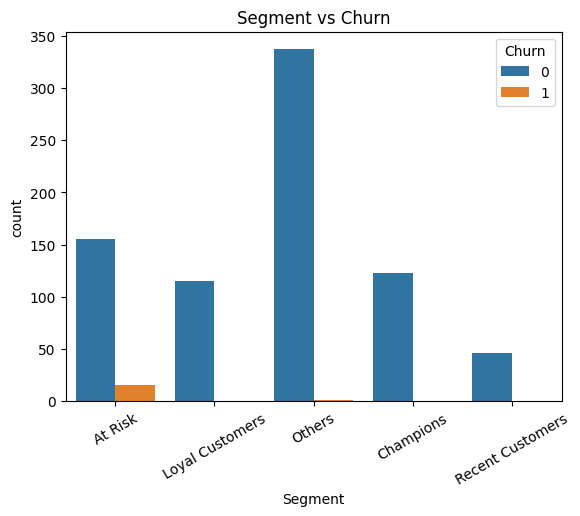


Business Insight:
- 'At Risk' segment contributes most to churn
- 'Champions' segment shows strong retention



In [7]:
# Analyze segment vs churn
sns.countplot(x="Segment", hue="Churn", data=rfm)
plt.title("Segment vs Churn")
plt.xticks(rotation=30)
plt.show()

print("""
Business Insight:
- 'At Risk' segment contributes most to churn
- 'Champions' segment shows strong retention
""")

## 🎯  Feature Selection

In [8]:
# Define feature set
features = [
    "Recency","Frequency","Monetary",
    "Tenure","AOV","Purchase_Frequency","Profit"
]

# Split features and target
X = rfm[features]
y = rfm["Churn"]

## 🔀 Train-Test Split

In [9]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## ⚖️ Feature Scaling

In [10]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Apply scaling to test data
X_test_scaled = scaler.transform(X_test)

## 🤖 Model Training

In [11]:
# Initialize XGBoost model
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

# Train model
model.fit(X_train_scaled, y_train)

print("Model training complete")

Model training complete


## 📉 Model Evaluation + Optimization

Best ROC Threshold: 0.4147
Best PR Threshold: 0.4147
Best Business Threshold: 0.1111

Final Model Performance
Threshold Used: 0.1111
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       156
           1       1.00      1.00      1.00         3

    accuracy                           1.00       159
   macro avg       1.00      1.00      1.00       159
weighted avg       1.00      1.00      1.00       159



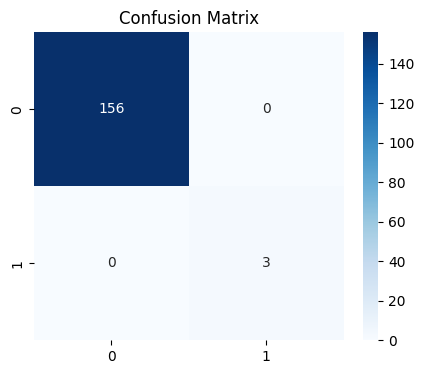

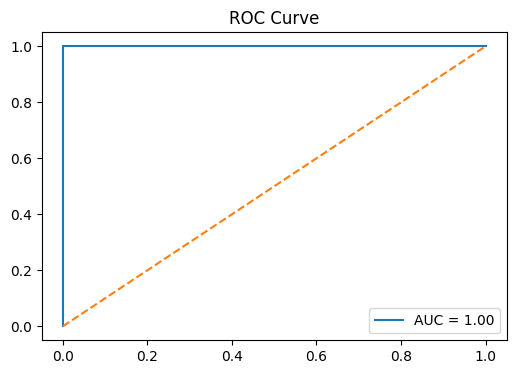

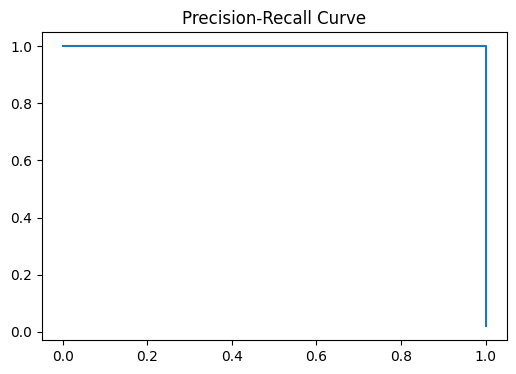

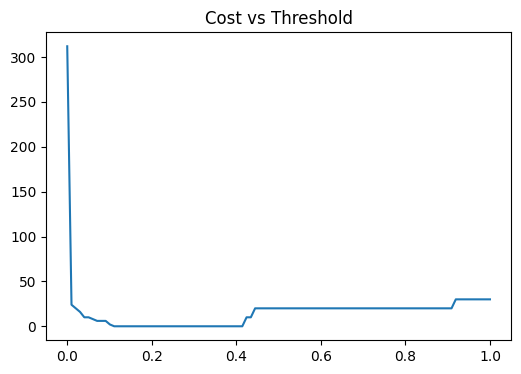

In [12]:
# Predict probabilities
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Optimize threshold using ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
j_scores = tpr - fpr
best_threshold_roc = roc_thresholds[np.argmax(j_scores)]

print(f"Best ROC Threshold: {best_threshold_roc:.4f}")

# Optimize threshold using precision-recall
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
best_threshold_pr = pr_thresholds[np.argmax(f1_scores)]

print(f"Best PR Threshold: {best_threshold_pr:.4f}")

# Optimize threshold based on business cost
cost_fn = 10
cost_fp = 2

thresholds = np.linspace(0, 1, 100)
costs = []

for t in thresholds:
    preds = (y_prob > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    costs.append((fn * cost_fn) + (fp * cost_fp))

threshold = thresholds[np.argmin(costs)]

print(f"Best Business Threshold: {threshold:.4f}")

# Generate final predictions
y_pred = (y_prob > threshold).astype(int)

# Evaluate model performance
print("\nFinal Model Performance")
print(f"Threshold Used: {threshold:.4f}")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Plot ROC curve
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.legend()
plt.title("ROC Curve")
plt.show()

# Plot precision-recall curve
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.show()

# Plot cost vs threshold
plt.figure(figsize=(6,4))
plt.plot(thresholds, costs)
plt.title("Cost vs Threshold")
plt.show()

## 🔍 Model Explainability

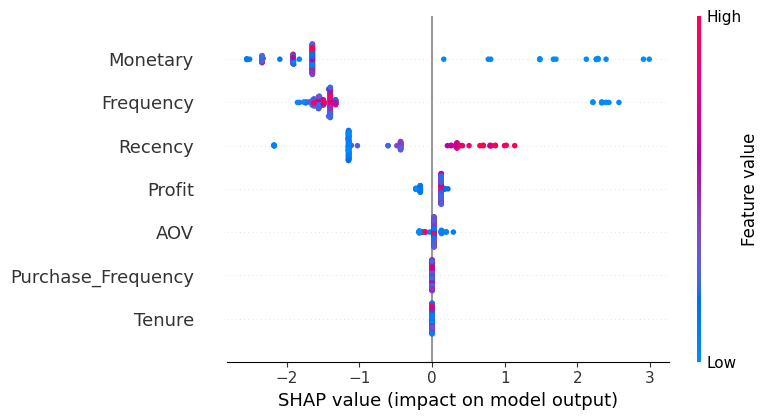

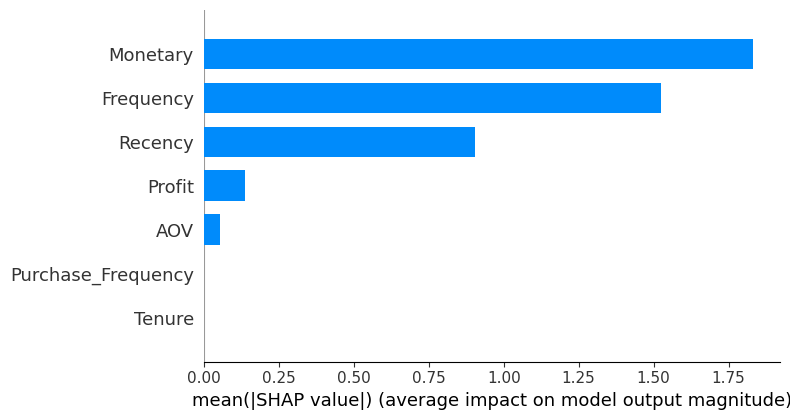

In [13]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_scaled)

# Plot feature impact
shap.summary_plot(shap_values, X_test)

# Plot feature importance (bar)
shap.summary_plot(shap_values, X_test, plot_type="bar")

## 📌 Experiment Tracking

In [14]:
# Set tracking URI
mlflow.set_tracking_uri("file:///content/mlruns")

# Set experiment
mlflow.set_experiment("Churn Prediction")

# Log run
with mlflow.start_run():

    # Log metrics
    mlflow.log_metric("auc", auc)
    mlflow.log_metric("threshold", threshold)

    # Log parameters
    mlflow.log_param("threshold_type", "business_optimized")
    mlflow.log_param("cost_fn", cost_fn)
    mlflow.log_param("cost_fp", cost_fp)

    # Log model
    mlflow.sklearn.log_model(model, "model")

print("MLflow tracking complete")

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/24 09:13:44 INFO mlflow.tracking.fluent: Experiment with name 'Churn Prediction' does not exist. Creating a new experiment.
2026/04/24 09:13:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 09:13:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' 

MLflow tracking complete


## 💾 Model Artifact Storage

In [15]:
# Create directory for model artifacts
os.makedirs("models", exist_ok=True)

# Save model and related artifacts
joblib.dump(model, "models/churn_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(X_test, "models/X_test.pkl")
joblib.dump(y_test, "models/y_test.pkl")

['models/y_test.pkl']

## 📡 Data Drift Monitoring

In [16]:
# Detect data drift using KS test
drift_results = []

for col in features:
    stat, p_value = ks_2samp(X_train[col], X_test[col])

    drift_results.append({
        "Feature": col,
        "KS Statistic": stat,
        "P-Value": p_value,
        "Drift_Flag": p_value < 0.05
    })

# Create drift summary
drift_df = pd.DataFrame(drift_results)

drift_df

,Feature,KS Statistic,P-Value,Drift_Flag
0,Recency,0.053171,0.840893,False
1,Frequency,0.067030,0.588475,False
2,Monetary,0.073180,0.477436,False
3,Tenure,0.053171,0.840893,False
4,AOV,0.096621,0.172781,False
5,Purchase_Frequency,0.067030,0.588475,False
6,Profit,0.054382,0.822058,False


## 📉 Drift Distribution Comparison

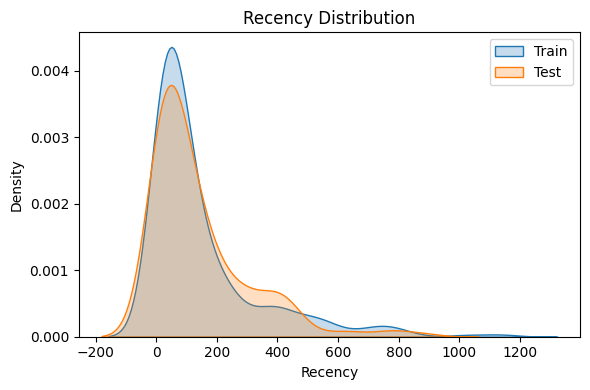

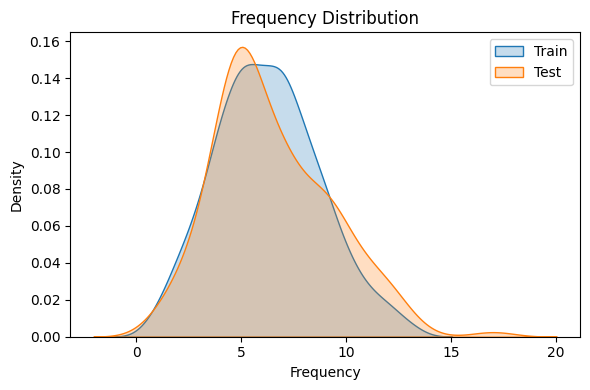

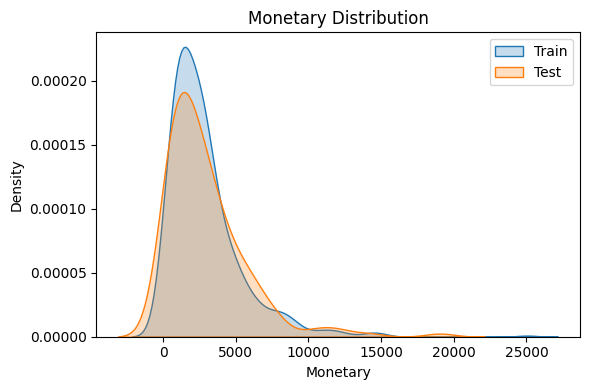

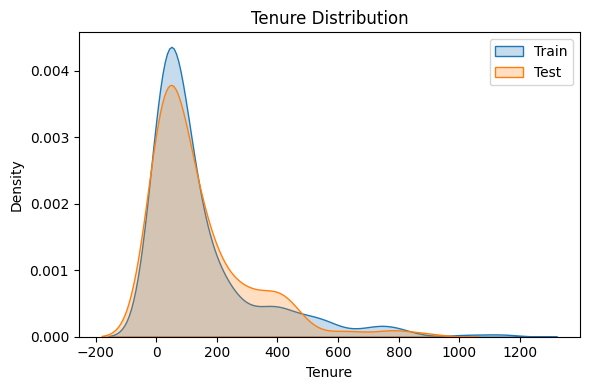

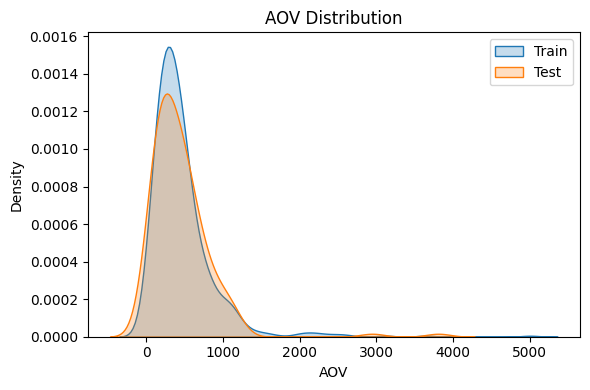

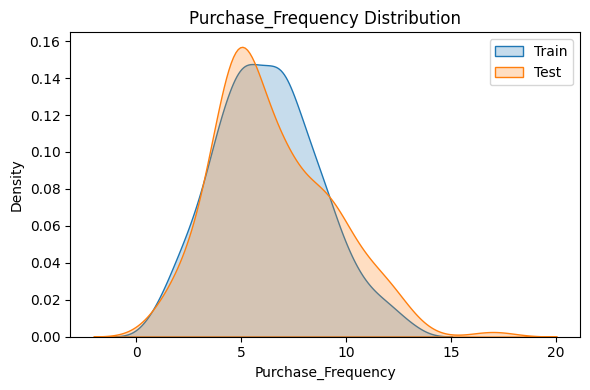

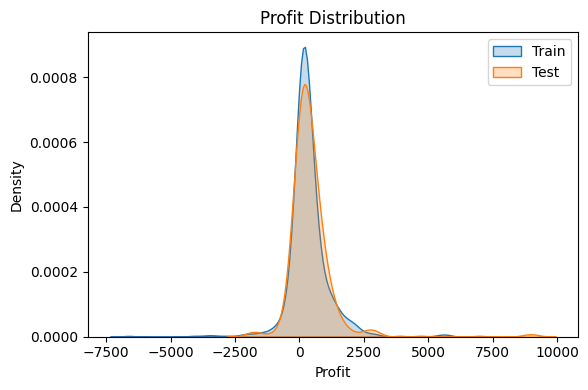

In [17]:
# Compare feature distributions (train vs test)
for col in features:
    plt.figure(figsize=(6,4))

    sns.kdeplot(X_train[col], label="Train", fill=True)
    sns.kdeplot(X_test[col], label="Test", fill=True)

    plt.title(f"{col} Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

## ⏱️ Auto Retrain Trigger

In [18]:
# Check for drift and trigger action
if drift_df["Drift_Flag"].any():
    print("Drift detected - retraining recommended")
else:
    print("No significant drift detected")

No significant drift detected


## 🔁 Retraining Pipeline

In [19]:
# Retrain model on new data
def retrain_model(new_data):
    X_new = new_data[features]
    y_new = new_data["Churn"]

    # Scale features
    X_scaled = scaler.fit_transform(X_new)

    # Fit model
    model.fit(X_scaled, y_new)

    # Save updated model
    joblib.dump(model, "models/churn_model.pkl")

## 🌐 API Validation Layer



In [20]:
# Validate input data
def validate_input(data):
    required_fields = [
        "Recency","Frequency","Monetary",
        "Tenure","AOV","Purchase_Frequency","Profit"
    ]

    for field in required_fields:
        # Check missing fields
        if field not in data:
            raise ValueError(f"Missing field: {field}")

        # Check invalid values
        if data[field] < 0:
            raise ValueError(f"Invalid value for {field}")

    return True


# Test validation with sample input
sample_input = {
    "Recency": 50,
    "Frequency": 5,
    "Monetary": 500,
    "Tenure": 50,
    "AOV": 100,
    "Purchase_Frequency": 5,
    "Profit": 200
}

validate_input(sample_input)

print("Input validation passed")

Input validation passed


## 🎖️ Customer Targeting Layer

In [21]:
# Generate predictions and probabilities
rfm["Churn_Probability"] = model.predict_proba(scaler.transform(X))[:, 1]
rfm["Prediction"] = model.predict(scaler.transform(X))

# Assign priority based on risk level
def assign_priority(row):
    if row["Churn_Probability"] > 0.8 and row["Segment"] == "At Risk":
        return "🔥 Critical"
    elif row["Churn_Probability"] > 0.7:
        return "⚠️ High"
    elif row["Churn_Probability"] > 0.5:
        return "⚡ Medium"
    else:
        return "✅ Low"

# Apply priority classification
rfm["Priority_Level"] = rfm.apply(assign_priority, axis=1)

## 🧭 Priority Visualization

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


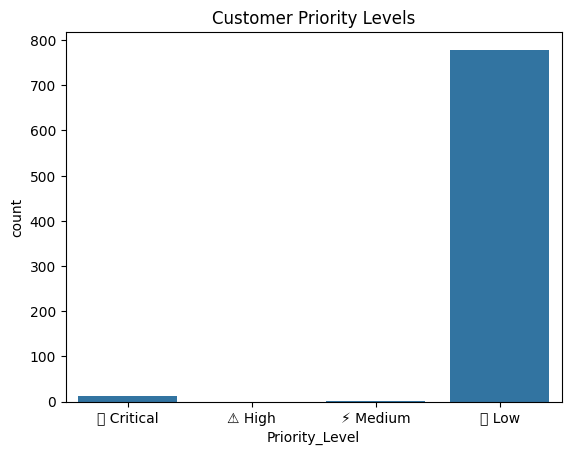

In [22]:
# Plot priority level distribution
sns.countplot(
    x="Priority_Level",
    data=rfm,
    order=["🔥 Critical","⚠️ High","⚡ Medium","✅ Low"]
)
plt.title("Customer Priority Levels")
plt.show()

## 🧾 Target Customer Output

In [23]:
# View top high-risk customers
rfm[["Customer ID","Segment","Churn_Probability","Priority_Level"]] \
    .sort_values(by="Churn_Probability", ascending=False) \
    .head(15)

,Customer ID,Segment,Churn_Probability,Priority_Level
49,AR-10570,At Risk,0.976977,🔥 Critical
650,RM-19750,At Risk,0.968617,🔥 Critical
374,JJ-15760,At Risk,0.956729,🔥 Critical
308,GP-14740,At Risk,0.956729,🔥 Critical
585,PB-19210,At Risk,0.948493,🔥 Critical
42,AO-10810,At Risk,0.941526,🔥 Critical
637,RE-19405,At Risk,0.939235,🔥 Critical
456,LD-16855,At Risk,0.939235,🔥 Critical
552,NB-18580,At Risk,0.937549,🔥 Critical
760,TS-21085,At Risk,0.918317,🔥 Critical


## 🔍 Key Insights

- Recency is the strongest predictor of churn, indicating disengagement is the primary risk signal  
- Low-frequency customers show consistently higher churn probability  
- Newly acquired customers exhibit elevated churn risk due to weak early engagement  
- High-value customers are not immune to churn, highlighting the need for continuous retention strategies  

---

## 💡 Business Recommendations

- Prioritize high-risk customers using probability-driven targeting  
- Strengthen onboarding to improve early-stage retention  
- Implement loyalty programs to increase repeat engagement  
- Integrate predictive monitoring to enable proactive intervention  

---

## 🧾 Conclusion

This project delivers an end-to-end machine learning system for churn prediction, combining:

- Robust feature engineering (RFM + behavioral features)  
- Predictive modeling with optimized decision thresholds  
- Explainability using SHAP for model transparency  
- Monitoring capabilities including data drift detection  

The system enables data-driven decision-making and scalable customer retention strategies.

---

## 🖥️ Deployment

- Frontend: Streamlit dashboard for interactive prediction and insights  
- Backend: FastAPI service for real-time inference  

## 📦 Project Packaging & Export

In [24]:
# Set project name
project_name = "customer_churn_intelligence"

# Create folders
os.makedirs(f"{project_name}/models", exist_ok=True)
os.makedirs(f"{project_name}/app", exist_ok=True)

# Copy model artifacts
shutil.copy("models/churn_model.pkl", f"{project_name}/models/")
shutil.copy("models/scaler.pkl", f"{project_name}/models/")
shutil.copy("models/X_test.pkl", f"{project_name}/models/")
shutil.copy("models/y_test.pkl", f"{project_name}/models/")

# Create requirements.txt
with open(f"{project_name}/requirements.txt", "w") as f:
    f.write("""pandas
numpy
scikit-learn
xgboost
imbalanced-learn
matplotlib
seaborn
shap
mlflow
joblib
streamlit
fastapi
pydantic
python-dotenv
""")

# Create zip
zip_name = f"{project_name}.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:
    for root, _, files in os.walk(project_name):
        for file in files:
            zipf.write(os.path.join(root, file))

print(f"Package created: {zip_name}")

Package created: customer_churn_intelligence.zip


## ⬇️ Download (Colab)

In [25]:
# Download package
from google.colab import files
files.download("customer_churn_intelligence.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>